# 03 · Advanced Analytics — Statistical & Modelling Deep-Dives

Notebooks `00`–`02` **built and exported** the warehouse. This notebook is where the
**analysis** happens: statistical and machine-learning methods that go beyond what a
Power BI measure can express. Each section is a self-contained investigation — a business
**question**, the **method**, the **code**, and a written **finding**.

| # | Method | Question it answers | Where the result lives |
|---|---|---|---|
| **3.1** | Gini Coefficient | How concentrated is customer spending? | Finding (this notebook) |
| **3.2** | Hypothesis Testing | Are two segments *really* different, or is it noise? | Finding (this notebook) |
| **3.3** | RFM Segmentation (K-means) | What natural customer segments exist? | → `outputs/models/customer_rfm_segments.csv` → Power BI |
| **3.4** | Market Basket Analysis | Which products sell together? | Finding (this notebook) |
| **3.5** | Return Propensity (logistic regression) | Which orders are likely to be returned? | → `outputs/models/order_item_return_scores.csv` → Power BI |
| **3.6** | A/B-Test Power Plan | How large a test do we need to detect an effect? | Finding (this notebook) |
| **3.7** | *(optional)* CLV / Survival Analysis | What is a customer worth over their lifetime? | Finding (this notebook) |

**Convention:** every section opens its own **read-only** DuckDB connection, pulls only
the columns it needs, and closes the connection at the end — so sections run
independently and never lock the warehouse against the pipeline notebook.

---

## 3.1 Gini Coefficient

**Question:** How concentrated is customer spending overall — do a small share of
customers drive a disproportionate share of revenue?

### Step 1 - Connect and pull the data

Read-only connection so it never conflicts with the pipeline notebook.

In [1]:
import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

connection = duckdb.connect("../artifacts/practice_analytics.duckdb", read_only=True)

customers = connection.execute(
    "SELECT customer_id, net_sales_value, country, acquisition_source FROM mart.customer_360"
).fetchdf()

print(f"Loaded {len(customers):,} customers")
customers.head()

Loaded 80,095 customers


,customer_id,net_sales_value,country,acquisition_source
0,65160,0.000000,China,Search
1,66503,213.059998,China,Organic
2,74713,227.149998,China,Search
3,84699,59.500000,China,Search
4,94002,263.960007,China,Search


### Step 2 - Write the Gini function, and validate it on a known example first

Before trusting it on real data, test it on cases where you already know the answer -
same "check against a known answer" habit used throughout the SQL/DAX work.

In [2]:
def gini(values):
    values = np.sort(np.asarray(values, dtype=float))
    n = len(values)
    index = np.arange(1, n + 1)
    return (2 * np.sum(index * values) - (n + 1) * np.sum(values)) / (n * np.sum(values))

# Sanity checks before trusting it on real data
assert round(gini([10, 10, 10, 10]), 4) == 0.0          # perfect equality -> 0
print("Perfect equality check:", gini([10, 10, 10, 10]))

print("Extreme inequality check (should be close to 1):", gini([0, 0, 0, 100]))
print("Mild inequality check (should be a small positive number):", gini([8, 9, 10, 13]))

Perfect equality check: 0.0
Extreme inequality check (should be close to 1): 0.75
Mild inequality check (should be a small positive number): 0.1


### Step 3 - Compute the real, overall Gini coefficient

This is the headline number for the whole customer base.

In [3]:
overall_gini = gini(customers["net_sales_value"])
print(f"Overall customer spending Gini coefficient: {overall_gini:.3f}")

Overall customer spending Gini coefficient: 0.580


### Step 4 - Explore across a few interesting cuts

Computing Gini per segment reveals *where* concentration is strongest, not just
that it exists overall.

In [4]:
for col in ["country", "acquisition_source"]:
    print(f"\nGini by {col}:")
    segment_gini = (
        customers.groupby(col)["net_sales_value"]
        .apply(gini)
        .sort_values(ascending=False)
    )
    print(segment_gini)


Gini by country:
country
Poland            0.593832
Spain             0.590697
Australia         0.584958
United States     0.580427
France            0.580237
South Korea       0.580203
United Kingdom    0.580010
Brasil            0.578718
China             0.578576
Japan             0.576746
Germany           0.575936
Belgium           0.553622
Colombia          0.524477
Deutschland       0.000000
España                 NaN
Name: net_sales_value, dtype: float64

Gini by acquisition_source:
acquisition_source
Search      0.580779
Organic     0.579619
Email       0.575509
Display     0.574519
Facebook    0.571016
Name: net_sales_value, dtype: float64


C:\Users\phanh\AppData\Local\Temp\ipykernel_24964\3245779619.py:5: RuntimeWarning: invalid value encountered in scalar divide
  return (2 * np.sum(index * values) - (n + 1) * np.sum(values)) / (n * np.sum(values))


### Step 5 - Plot the Lorenz curve

The formal picture behind the Gini number: cumulative % of customers (x-axis) vs.
cumulative % of revenue (y-axis). The further the curve bows below the 45-degree
"perfect equality" line, the more concentrated spending is.

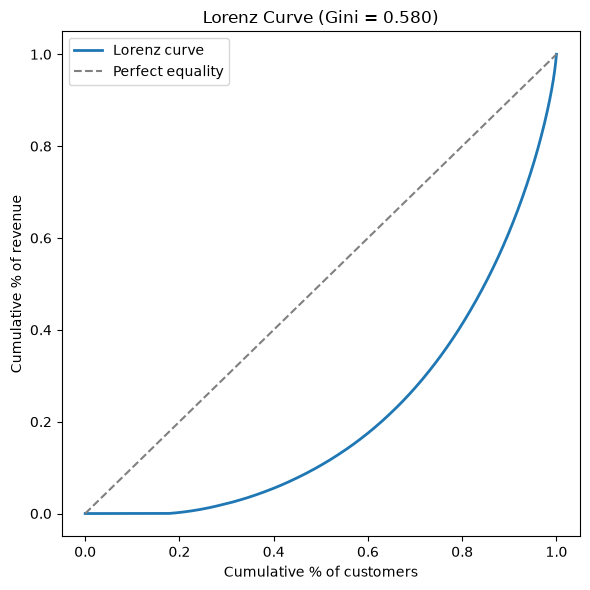

In [5]:
sorted_vals = np.sort(customers["net_sales_value"].to_numpy())
cum_customers = np.arange(1, len(sorted_vals) + 1) / len(sorted_vals)
cum_revenue = np.cumsum(sorted_vals) / sorted_vals.sum()

plt.figure(figsize=(6, 6))
plt.plot(cum_customers, cum_revenue, label="Lorenz curve", linewidth=2)
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Perfect equality")
plt.xlabel("Cumulative % of customers")
plt.ylabel("Cumulative % of revenue")
plt.title(f"Lorenz Curve (Gini = {overall_gini:.3f})")
plt.legend()
plt.tight_layout()
plt.show()

### Step 6 - Write the findings

Fill this in after running the cells above. Cover:

- **The overall Gini number** and what it means in plain English (closer to 1 = more
  concentrated spending among fewer customers).
- **Which segment(s) stood out** in the Step 4 breakdown - did any country or
  acquisition source show noticeably higher/lower concentration?
- **One caveat** - this is synthetic data, so the concentration pattern reflects
  the dataset's generation process, not necessarily a real market's dynamics.

> *(Your written conclusion goes here once you've seen the actual numbers.)*

### Step 7 - Close the connection

In [6]:
connection.close()
print("Connection closed.")

Connection closed.


---

## 3.2 Hypothesis Testing

Section 3.1 measured *how concentrated* spending is. This section asks a different kind of
question: when we split customers into groups and the groups *look* different, is the
difference **real**, or just random sampling noise? That is what hypothesis testing decides.

"Comparing groups" comes in three shapes, each with its own correct test — so this section
is really three mini-analyses that together form the standard group-comparison toolkit:

| # | Test | Compares | Question here |
|---|---|---|---|
| **3.2.1** | Two-sample **t-test** | 2 group means | Do **male vs female** customers differ in AOV? |
| **3.2.2** | **ANOVA** | 3+ group means | Does AOV differ across the **5 acquisition channels**? |
| **3.2.3** | **Chi-square** | categorical proportions | Does **return rate** differ across product **categories**? |

Every test follows the same ritual: state H0/H1 -> pick alpha -> compute a **p-value**
(*is the difference real?*) -> compute an **effect size** (*is it big enough to matter?*).
Watch how, on this synthetic data, the answer is almost always "**detectable at most, but
negligible in size**" — the single most important lesson in not chasing significance alone.

### 3.2.1 Two-sample t-test — male vs female AOV

**Question:** Do **male** and **female** customers spend a different amount **per order**
(AOV)? The two-sample t-test compares the *means* of a continuous number between two
independent groups — the natural fit for a dimension with exactly two values.

### Step 1 - State the hypotheses (before touching the data)

A hypothesis test always starts by writing down two competing claims **before** you look
at the result, so you can't be tempted to move the goalposts afterwards.

- **Null hypothesis (H0):** male and female customers have the **same** mean AOV.
  Any difference we see in the sample is just random noise. *(This is the "nothing
  interesting is happening" default — assumed true until the data forces us to reject it.)*
- **Alternative hypothesis (H1):** the two groups have a **different** mean AOV.

**Significance level (alpha) = 0.05** — the risk we accept of wrongly rejecting H0
(a "false alarm": claiming a difference that isn't real). 0.05 = "I'll accept a 5% chance."

**Two-sided test:** we ask "is it *different*" (could be higher or lower), not "is it
*higher*", so we test both directions.

The test produces a **p-value**: the probability of seeing a gap this big (or bigger)
*if H0 were true*. A small p-value means the data would be very surprising under
"no difference", so we reject H0. Decision rule: **p < alpha -> reject H0** (the
difference is statistically significant).

### Step 2 - Connect and pull the two groups

Its own read-only connection. We pull just two columns from `customer_360`: the outcome
we're testing (`average_order_value`) and the column that splits customers into the two
groups (`gender`). We keep only `'M'` and `'F'` rows so the two groups are clean.

In [7]:
import duckdb
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

connection = duckdb.connect("../artifacts/practice_analytics.duckdb", read_only=True)

df = connection.execute(
    "SELECT average_order_value, gender FROM mart.customer_360 WHERE gender IN ('M', 'F')"
).fetchdf()

# Split into the two independent groups
male   = df.loc[df["gender"] == "M", "average_order_value"].to_numpy()
female = df.loc[df["gender"] == "F", "average_order_value"].to_numpy()

print(f"Male customers   : {len(male):,}")
print(f"Female customers : {len(female):,}")

Male customers   : 40,234
Female customers : 39,861


### Step 3 - Look before you test (describe and visualise)

Never jump straight to the test. First look at the two groups' means, spreads, and shapes
— the test only *formalises* what your eyes should already suspect, and a plot catches
problems (extreme skew, weird outliers) that a single p-value would hide.

Male     n=40,234  mean=$  69.34  median=$  46.07  std=$  85.98
Female   n=39,861  mean=$  60.57  median=$  39.74  std=$  74.17

Observed difference in mean AOV: $8.78


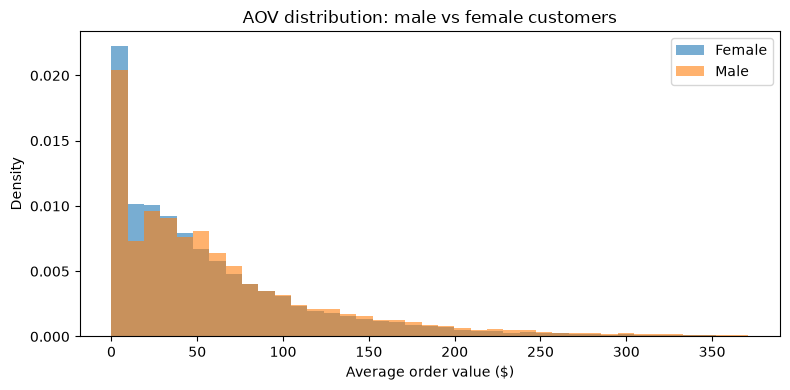

In [8]:
for name, group in [("Male", male), ("Female", female)]:
    print(f"{name:7s}  n={len(group):>6,}  mean=${group.mean():7.2f}  "
          f"median=${np.median(group):7.2f}  std=${group.std(ddof=1):7.2f}")

observed_gap = male.mean() - female.mean()
print(f"\nObserved difference in mean AOV: ${observed_gap:,.2f}")

# Density histograms (density=True) so the two groups are comparable despite different sizes.
# Cap the x-axis at the 99th percentile so a few extreme values don't squash the picture.
plt.figure(figsize=(8, 4))
bins = np.linspace(0, np.percentile(df["average_order_value"], 99), 40)
plt.hist(female, bins=bins, alpha=0.6, label="Female", density=True)
plt.hist(male,   bins=bins, alpha=0.6, label="Male",   density=True)
plt.xlabel("Average order value ($)")
plt.ylabel("Density")
plt.title("AOV distribution: male vs female customers")
plt.legend()
plt.tight_layout()
plt.show()

### Step 4 - Run the two-sample t-test (Welch's)

`scipy.stats.ttest_ind` compares two group means. We pass `equal_var=False`, which runs
**Welch's t-test** — the safer default that does **not** assume the two groups have equal
variance (real-world groups rarely do). It returns:

- **t-statistic** — how many standard errors apart the two means are. Bigger magnitude =
  groups further apart relative to the noise.
- **p-value** — the probability of a gap this large if H0 (no real difference) were true.

In [9]:
t_stat, p_value = stats.ttest_ind(male, female, equal_var=False)

print(f"t-statistic: {t_stat:.3f}")
print(f"p-value    : {p_value:.3g}")

alpha = 0.05
if p_value < alpha:
    print(f"\np < {alpha}  ->  REJECT H0: the difference in mean AOV is statistically significant.")
else:
    print(f"\np >= {alpha}  ->  FAIL TO REJECT H0: no statistically significant difference.")

t-statistic: 15.475
p-value    : 6.11e-54

p < 0.05  ->  REJECT H0: the difference in mean AOV is statistically significant.


### Step 5 - Measure the effect size (is the difference big enough to matter?)

Here's the catch every analyst must understand: with a large sample (we have ~80,000
customers), the t-test will call **even a tiny, business-irrelevant difference**
"statistically significant". A p-value tells you the difference is *real*; it does **not**
tell you it's *big*.

So we also compute **Cohen's d** — the size of the gap measured in standard deviations,
independent of sample size. Rough convention:

| Cohen's d | Practical meaning |
|---|---|
| ~0.2 | small |
| ~0.5 | medium |
| ~0.8 | large |

A significant p-value **and** a meaningful d = a difference worth acting on. Significant p
but d ~ 0.05 = "real, but too small to care about".

In [10]:
# Cohen's d using a pooled standard deviation
n1, n2 = len(male), len(female)
pooled_std = np.sqrt(
    ((n1 - 1) * male.var(ddof=1) + (n2 - 1) * female.var(ddof=1)) / (n1 + n2 - 2)
)
cohens_d = (male.mean() - female.mean()) / pooled_std

print(f"Cohen's d: {cohens_d:.3f}")

magnitude = (
    "negligible" if abs(cohens_d) < 0.2 else
    "small"      if abs(cohens_d) < 0.5 else
    "medium"     if abs(cohens_d) < 0.8 else
    "large"
)
print(f"Effect size is {magnitude}.")

Cohen's d: 0.109
Effect size is negligible.


### Step 6 - Write the findings

Fill this in after running the cells above. A complete finding states **all four**:

- **The decision** — did we reject H0? (p vs alpha)
- **The direction & size** — which group is higher, by how many dollars, and how big is
  Cohen's d?
- **The business reading** — does the difference actually matter for a decision, or is it
  "significant but trivial"? With ~80k customers, watch for a tiny p-value paired with a
  negligible Cohen's d.
- **One caveat** — this is synthetic data, so any gender gap reflects the generator's
  design, not a real behavioural difference; never build a real pricing/targeting policy
  on a single test like this.

> *(Your written conclusion goes here once you've seen the actual numbers.)*

### Step 7 - Close the connection

In [11]:
connection.close()
print("Connection closed.")

Connection closed.


### 3.2.2 ANOVA — AOV across the 5 acquisition channels

A t-test only compares **two** groups. With **five** channels (Display, Email, Facebook,
Organic, Search) we'd need 10 separate pairwise t-tests to check every combination — and
each test carries a 5% false-alarm risk, so running many of them almost guarantees a fluke
"significant" result (the **multiple-comparisons** problem). **ANOVA** (Analysis of Variance)
solves this with a single test for *"do **any** of the group means differ?"*

- **H0:** all five channels have the **same** mean AOV.
- **H1:** **at least one** channel's mean AOV differs.
- **alpha = 0.05.** The statistic is **F** = (variation *between* groups) / (variation
  *within* groups). A large F with a small p means the groups sit further apart than the
  within-group noise can explain.

In [12]:
import duckdb
import numpy as np
from scipy import stats

connection = duckdb.connect("../artifacts/practice_analytics.duckdb", read_only=True)
chan = connection.execute(
    "SELECT average_order_value, acquisition_source FROM mart.customer_360"
).fetchdf()
connection.close()

# One AOV array per channel — the input ANOVA expects
groups = [g["average_order_value"].to_numpy() for _, g in chan.groupby("acquisition_source")]
labels = [name for name, _ in chan.groupby("acquisition_source")]

for name, g in zip(labels, groups):
    print(f"{name:9s}  n={len(g):>6,}  mean AOV=${g.mean():.2f}")

f_stat, p_value = stats.f_oneway(*groups)
print(f"\nF-statistic: {f_stat:.3f}")
print(f"p-value    : {p_value:.3g}")
print("REJECT H0" if p_value < 0.05 else "FAIL TO REJECT H0  (channels look interchangeable)")

Display    n= 3,206  mean AOV=$63.87
Email      n= 4,058  mean AOV=$65.54
Facebook   n= 4,796  mean AOV=$65.87
Organic    n=11,949  mean AOV=$64.79
Search     n=56,086  mean AOV=$64.96

F-statistic: 0.366
p-value    : 0.833
FAIL TO REJECT H0  (channels look interchangeable)


**Effect size — eta-squared (eta^2).** ANOVA's answer to Cohen's d: the share of the total
variation in AOV that is explained by *which channel* a customer came from. Rough guide:
~0.01 small, ~0.06 medium, ~0.14 large. If eta^2 is near 0, channel tells you essentially
nothing about how much a customer spends per order.

In [13]:
grand_mean = chan["average_order_value"].mean()
ss_between = sum(len(g) * (g.mean() - grand_mean) ** 2 for g in groups)
ss_total = ((chan["average_order_value"] - grand_mean) ** 2).sum()
eta_sq = ss_between / ss_total
print(f"eta-squared: {eta_sq:.4f}")

eta-squared: 0.0000


**Finding (3.2.2):** *(fill after running)* F ≈ ____, p ≈ ____, eta^2 ≈ ____. Do the five
channels differ in AOV — and even if p is small, is eta^2 large enough to matter?

### 3.2.3 Chi-square — return rate across product categories

The first two tests compared a **numeric average** (AOV). Return behaviour is different:
each item is either **returned or not** — a yes/no **proportion**, not an average. For
*"is a categorical outcome (returned?) related to a categorical group (product category)?"*
the right tool is the **chi-square test of independence**, run on a table of **counts**.

- **H0:** return rate is the **same** across all categories — returning is *independent* of
  category.
- **H1:** **at least one** category has a different return rate.
- We build a **contingency table** (category × returned / not-returned) from return-eligible
  items, and `chi2_contingency` compares the **observed** counts to the counts H0 predicts.

In [14]:
import duckdb
import numpy as np
from scipy import stats

connection = duckdb.connect("../artifacts/practice_analytics.duckdb", read_only=True)
ct = connection.execute(
    """
    SELECT p.category,
           SUM(f.returned_item_flag)                                 AS returned,
           SUM(CASE WHEN f.returned_item_flag = 0 THEN 1 ELSE 0 END) AS not_returned
    FROM core.fact_order_item f
    JOIN core.dim_product p ON f.product_id = p.product_id
    WHERE f.return_observation_eligible_flag = 1
    GROUP BY p.category
    HAVING COUNT(*) > 200
    """
).fetchdf()
connection.close()

ct["return_rate"] = ct["returned"] / (ct["returned"] + ct["not_returned"])
print("Highest / lowest return-rate categories:")
print(ct.sort_values("return_rate", ascending=False).head(3).to_string(index=False))
print(ct.sort_values("return_rate").head(3).to_string(index=False))

# The contingency table is just the two count columns
table = ct[["returned", "not_returned"]].to_numpy()
chi2, p_value, dof, expected = stats.chi2_contingency(table)
print(f"\nchi2 = {chi2:.2f}   dof = {dof}   p-value = {p_value:.3g}")
print("REJECT H0" if p_value < 0.05 else "FAIL TO REJECT H0  (return rate is flat across categories)")

Highest / lowest return-rate categories:
           category  returned  not_returned  return_rate
Jumpsuits & Rompers     116.0         217.0     0.348348
             Skirts     227.0         514.0     0.306343
     Pants & Capris     360.0         855.0     0.296296
         category  returned  not_returned  return_rate
  Socks & Hosiery     341.0         964.0     0.261303
Blazers & Jackets     287.0         794.0     0.265495
        Maternity     456.0        1219.0     0.272239

chi2 = 28.12   dof = 24   p-value = 0.255
FAIL TO REJECT H0  (return rate is flat across categories)


**Effect size — Cramer's V.** The chi-square counterpart to Cohen's d: the strength of the
association between category and returning, on a 0–1 scale (~0.1 small, ~0.3 medium, ~0.5
large). Near 0 means category and return behaviour are essentially unrelated — a significant
p with V ≈ 0 is again "real but trivial".

In [15]:
n = table.sum()
k = min(table.shape) - 1
cramers_v = np.sqrt(chi2 / (n * k))
print(f"Cramer's V: {cramers_v:.4f}")

Cramer's V: 0.0211


**Finding (3.2.3):** *(fill after running)* chi2 ≈ ____, p ≈ ____, Cramer's V ≈ ____.

### 3.2 Findings — synthesis

*(Fill in after running all three tests.)* Across three different lenses — gender (t-test),
channel (ANOVA), category (chi-square) — the pattern is consistent:

- **t-test (gender AOV):** the gap is *statistically significant* (p is tiny) but the
  **effect size is negligible** (Cohen's d ≈ ____) — a textbook case of a large sample making
  a trivial gap "significant".
- **ANOVA (channel AOV):** the channels are **not even statistically different** (p ≈ ____,
  eta^2 ≈ ____).
- **Chi-square (category return rate):** return rate is **flat across categories**
  (p ≈ ____, Cramer's V ≈ ____).

**Business reading:** on these dimensions the customer base is statistically **homogeneous**
— which echoes the Gini result (concentration is uniform across segments). The actionable
lever is *not* demographic / channel / category targeting, but the **within-customer
concentration** from 3.1: focus on the high-value tail, not on "men vs women" or
"Email vs Facebook".

**Caveat:** this is synthetic data, so the flatness reflects theLook's generator, not a real
market — in real data you would expect at least some of these tests to find a genuine,
sizeable difference. The *method* (test -> p-value -> effect size -> honest read) is what
transfers.

---

## 3.3 RFM Segmentation with K-means

Sections 3.1 and 3.2 *measured* and *tested*. This section **builds an asset**: a
segment label for every customer that flows **back into Power BI** as a slicer — the
first of two models whose output leaves this notebook and becomes part of the dashboard.

**Business problem.** Marketing currently spends the same attention on all 80,095
customers. They can't separate a *Champion* (buys often, recently, spends a lot) from a
one-time buyer who churned a year ago. With no segments, retention budget is sprayed
evenly instead of aimed where it pays back.

**RFM** compresses each customer's behaviour into three numbers — the three questions a
retention manager actually asks:

| Letter | Meaning | Column | A *good* customer… |
|---|---|---|---|
| **R** — Recency | days since last order | `recency_days` | ordered **recently** → *low* |
| **F** — Frequency | number of orders | `order_count` | orders **often** → *high* |
| **M** — Monetary | total net spend | `net_sales_value` | spends **a lot** → *high* |

**Why K-means (not hand-drawn cut-offs).** We could bucket each of R/F/M into "high/med/low"
by hand, but that imposes *our* boundaries. **K-means** lets the data reveal its own natural
groupings in R-F-M space. The output — one segment label per customer — is exported to CSV
and imported into Power BI.

**Roadmap:** pull R/F/M → inspect & scale → choose *k* → fit → profile & **name** the
clusters → export for Power BI → finding.

### Step 1 - Connect and pull the RFM inputs

Own read-only connection. We pull exactly the three RFM columns plus the customer key, and
keep only customers who actually spent something (`net_sales_value > 0`) so the Monetary
axis is meaningful.

In [16]:
import duckdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

connection = duckdb.connect("../artifacts/practice_analytics.duckdb", read_only=True)
rfm = connection.execute("""
    SELECT customer_id, recency_days, order_count, net_sales_value
    FROM mart.customer_360
    WHERE net_sales_value > 0
""").fetchdf()
connection.close()

print(f"Loaded {len(rfm):,} customers")
rfm.head()

Loaded 66,215 customers


,customer_id,recency_days,order_count,net_sales_value
0,66503,104,4,213.059998
1,74713,62,2,227.149998
2,84699,167,1,59.500000
3,94002,561,2,263.960007
4,2979,129,2,9.950000


### Step 2 - Look at the three distributions (why scaling is not optional)

K-means groups points by **Euclidean distance**. Look at the raw ranges below: Monetary runs
into the hundreds/thousands of dollars, Recency into hundreds of days, Frequency is single
digits. If we feed those in raw, **Monetary's large numbers dominate the distance** and
Frequency barely counts — the clusters would be "Monetary bands" wearing an RFM costume.

The histograms also show a strong **right skew** (a long tail of big spenders / very stale
customers). Both problems have a standard two-step fix in the next cell.

       recency_days  order_count  net_sales_value
count       66215.0      66215.0          66215.0
mean          398.3          1.7            122.3
std           395.6          0.9            127.5
min             0.0          1.0              0.0
25%            86.0          1.0             38.9
50%           263.0          1.0             79.9
75%           598.0          2.0            163.0
max          1951.0          4.0           1747.3


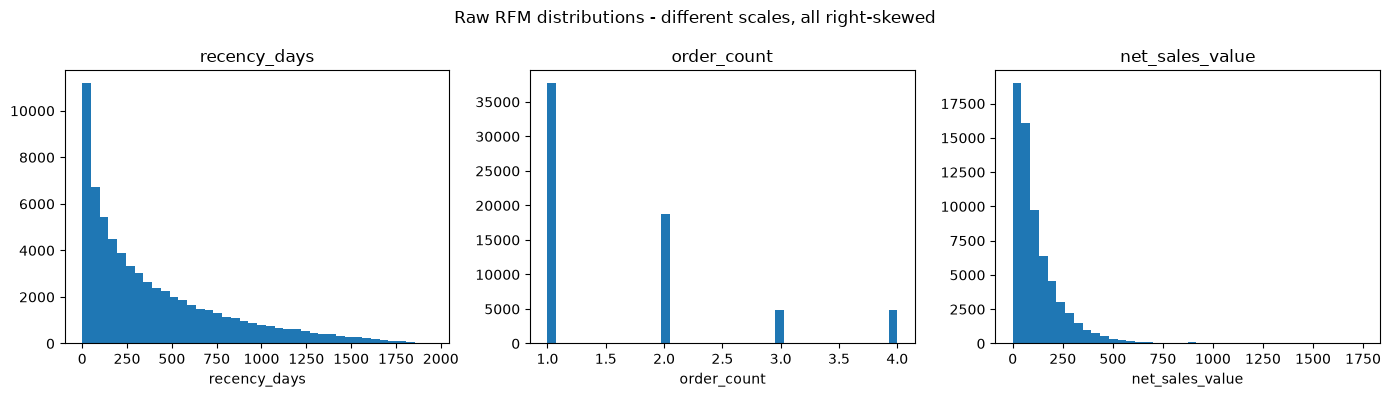

In [17]:
print(rfm[["recency_days", "order_count", "net_sales_value"]].describe().round(1))

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col in zip(axes, ["recency_days", "order_count", "net_sales_value"]):
    ax.hist(rfm[col], bins=40)
    ax.set_title(col)
    ax.set_xlabel(col)
plt.suptitle("Raw RFM distributions - different scales, all right-skewed")
plt.tight_layout()
plt.show()

### Step 3 - Preprocess: log-transform, then standardize

Two steps, each fixing one problem from Step 2:

1. **`np.log1p`** (log of 1+x) squashes the long right tail so a handful of whales don't
   define a whole cluster. `log1p` is used instead of `log` because it is safe at 0
   (`log1p(0) = 0`).
2. **`StandardScaler`** rescales each column to **mean 0, standard deviation 1**, so R, F and
   M each contribute *equally* to the distance — no unit (dollars vs days) gets to dominate.

After this, a value of `0` means "an average customer on this axis", `+1` means "one standard
deviation above average", and so on.

In [18]:
features = ["recency_days", "order_count", "net_sales_value"]

X_log = np.log1p(rfm[features])           # tame the right-skew; safe at 0
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_log)    # each feature -> mean 0, sd 1

print("Scaled means:", X_scaled.mean(axis=0).round(3), " -> all ~0")
print("Scaled stds :", X_scaled.std(axis=0).round(3), " -> all ~1")

Scaled means: [-0.  0. -0.]  -> all ~0
Scaled stds : [1. 1. 1.]  -> all ~1


### Step 4 - Choose *k*: the elbow and the silhouette

K-means needs to be told *how many* clusters. Two standard diagnostics, run for k = 2…8:

- **Inertia (elbow method)** — total within-cluster distance. It *always* falls as k rises
  (more clusters = tighter groups), so we don't pick the minimum; we look for the **elbow**,
  the k after which extra clusters stop buying much tightness.
- **Silhouette score** (−1 to +1) — how well-separated the clusters are. **Higher is better.**
  Unlike inertia, it has a real maximum, so it can point at a "best" k directly.

We read both, then combine them with a business constraint: the segments have to be *few
enough to name and act on*.

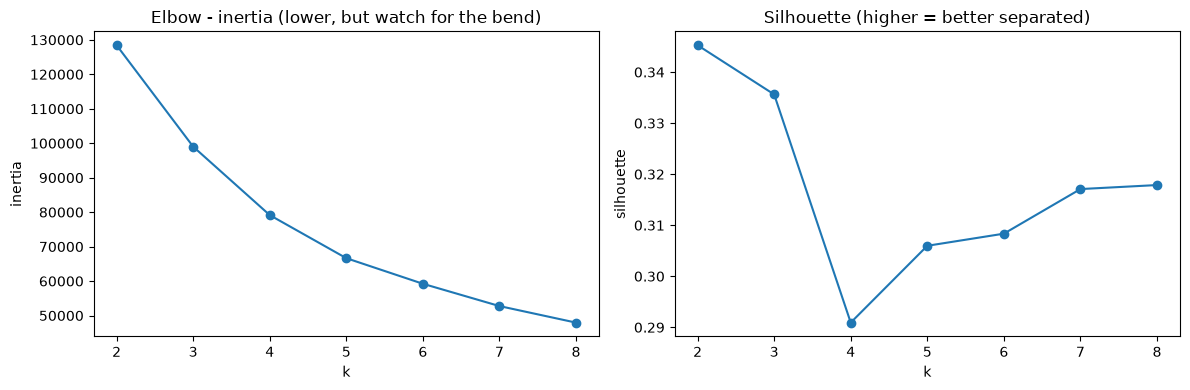

k=2  silhouette=0.345
k=3  silhouette=0.336
k=4  silhouette=0.291
k=5  silhouette=0.306
k=6  silhouette=0.308
k=7  silhouette=0.317
k=8  silhouette=0.318


In [19]:
inertias, silhouettes = [], []
ks = range(2, 9)

for k in ks:
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))

fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 4))
a1.plot(list(ks), inertias, "o-")
a1.set_title("Elbow - inertia (lower, but watch for the bend)")
a1.set_xlabel("k"); a1.set_ylabel("inertia")
a2.plot(list(ks), silhouettes, "o-")
a2.set_title("Silhouette (higher = better separated)")
a2.set_xlabel("k"); a2.set_ylabel("silhouette")
plt.tight_layout()
plt.show()

for k, s in zip(ks, silhouettes):
    print(f"k={k}  silhouette={s:.3f}")

### Step 5 - Fit the final model

We fit K-means with **k = 4** — a balance of the elbow/silhouette signal above and the
practical need for a handful of segments a marketer can name and target. Two settings matter:

- **`n_init=10`** — K-means starts from random seed points and can land in a bad local
  solution. It reruns 10 times and keeps the best, making the result stable.
- **`random_state=42`** — fixes that randomness so the notebook is **reproducible**: you and I
  get the identical clusters every run.

If Step 4 clearly favoured a different k on your run, change `K` below to match.

In [20]:
K = 4
kmeans = KMeans(n_clusters=K, n_init=10, random_state=42)
rfm["cluster"] = kmeans.fit_predict(X_scaled)

print("Customers per cluster:")
print(rfm["cluster"].value_counts().sort_index())

Customers per cluster:
cluster
0    11507
1    20752
2    13269
3    20687
Name: count, dtype: int64


### Step 6 - Profile and **name** the clusters

The cluster *numbers* (0,1,2,3) are meaningless labels — K-means assigns them randomly. The
analyst's job is to read each cluster's **average R, F and M** and translate it into a name a
human understands.

The naming code does this **robustly**: it ranks the clusters on each axis (inverting Recency,
because *low* recency is good), sums the ranks into an overall quality score, and assigns
names best→worst. That way the names track the *behaviour*, not the random cluster number —
rerun the notebook and "Champions" is still the best group even if its cluster id changed.

In [21]:
# Average RFM per cluster (in original units, for readability)
profile = rfm.groupby("cluster")[features].mean().round(1)
profile["customers"] = rfm["cluster"].value_counts().sort_index()
profile["pct"] = (100 * profile["customers"] / len(rfm)).round(1)
print("Cluster profiles (original units):")
print(profile)

# --- Robust naming: rank clusters on each axis, invert recency (low = good) ---
rank = profile[features].rank()                      # 1 = smallest value
rank["recency_days"] = rank["recency_days"].max() - rank["recency_days"] + 1  # invert
quality = rank["recency_days"] + rank["order_count"] + rank["net_sales_value"]

names_by_rank = ["Champions", "Loyal", "At-Risk", "Hibernating"]  # best -> worst
order = quality.sort_values(ascending=False).index.tolist()
segment_names = {cluster_id: name for cluster_id, name in zip(order, names_by_rank)}

rfm["segment"] = rfm["cluster"].map(segment_names)
print("\nCluster -> segment name:", segment_names)
print("\nSegment sizes:")
print(rfm["segment"].value_counts())

Cluster profiles (original units):
         recency_days  order_count  net_sales_value  customers   pct
cluster                                                             
0                37.1          1.4             83.4      11507  17.4
1               565.4          1.2             32.7      20752  31.3
2               181.8          3.1            238.2      13269  20.0
3               570.4          1.4            159.4      20687  31.2

Cluster -> segment name: {2: 'Champions', 0: 'Loyal', 3: 'At-Risk', 1: 'Hibernating'}

Segment sizes:
segment
Hibernating    20752
At-Risk        20687
Champions      13269
Loyal          11507
Name: count, dtype: int64


### Step 7 - Visualize the segment personalities (snake plot)

A **snake plot** shows each segment's *scaled* mean on all three axes at once. Because the
values are scaled (0 = average customer), you read the shape directly: a line **above 0** on
Frequency and Monetary but **below 0** on Recency is a Champion; the mirror image is a
Hibernating customer. It is the single clearest picture of "what makes each segment different".

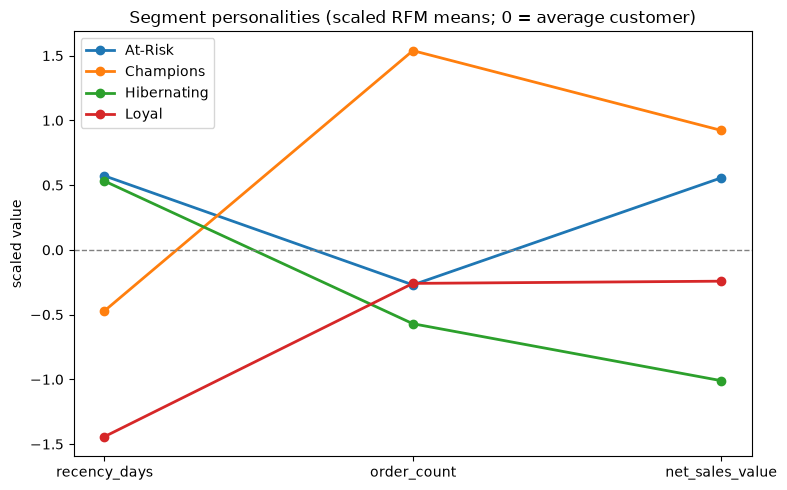

In [22]:
scaled_df = pd.DataFrame(X_scaled, columns=features)
scaled_df["segment"] = rfm["segment"].values
snake = scaled_df.groupby("segment")[features].mean()

plt.figure(figsize=(8, 5))
for seg in snake.index:
    plt.plot(features, snake.loc[seg], "o-", label=seg, linewidth=2)
plt.axhline(0, color="gray", linestyle="--", linewidth=1)
plt.title("Segment personalities (scaled RFM means; 0 = average customer)")
plt.ylabel("scaled value")
plt.legend()
plt.tight_layout()
plt.show()

### Step 8 - Export the segment table for Power BI  ← the tool-to-tool handoff

This is where the model **leaves Python and enters the dashboard**. We write one row per
customer — the key plus the assigned segment — to `outputs/models/customer_rfm_segments.csv`.

In Power BI you then **Get Data → Text/CSV** on this file and create a **relationship** from
`customer_rfm_segments[customer_id]` to `dim_customer[user_id]` (1-to-1). `segment` becomes a
slicer and a legend across every existing customer visual — no existing table is modified.

In [23]:
from pathlib import Path

out_dir = Path("../outputs/models")
out_dir.mkdir(parents=True, exist_ok=True)

export = rfm[["customer_id", "recency_days", "order_count",
              "net_sales_value", "cluster", "segment"]]
out_path = out_dir / "customer_rfm_segments.csv"
export.to_csv(out_path, index=False)

print(f"Wrote {len(export):,} rows -> {out_path.resolve()}")
export.head()

Wrote 66,215 rows -> C:\Users\phanh\data_analysis\p_projects\the_look_ecommerce\practice_analysis\outputs\models\customer_rfm_segments.csv


,customer_id,recency_days,order_count,net_sales_value,cluster,segment
0,66503,104,4,213.059998,2,Champions
1,74713,62,2,227.149998,2,Champions
2,84699,167,1,59.500000,1,Hibernating
3,94002,561,2,263.960007,3,At-Risk
4,2979,129,2,9.950000,1,Hibernating


### Step 9 - Write the findings

Fill in after running the cells above. A complete finding states:

- **The segments you found** — their names, sizes (% of base), and the R/F/M signature that
  defines each (quote the Step 6 profile table).
- **The money at stake** — which segment holds the most revenue (Champions are usually few but
  large), and which is the biggest *opportunity* (At-Risk = was valuable, slipping away).
- **The action per segment** — e.g. protect Champions with loyalty perks, win back At-Risk with
  a targeted offer, don't overspend on Hibernating.
- **One caveat** — synthetic data, so segment *shapes* reflect theLook's generator; the
  *method* is what transfers.

> *(Your written conclusion goes here once you've seen the actual numbers.)*

---

## 3.4 Market Basket Analysis

*(Reserved — written-finding section, to be built next. Placed here to preserve the roadmap
numbering; Section 3.5 below is the second model that feeds Power BI.)*

---

## 3.5 Return Propensity — Logistic Regression

The second **model that feeds Power BI**. Where 3.3 grouped customers, this one **predicts an
event**.

**Business problem.** Every return burns margin — reverse shipping, restocking labour, and
often a markdown on the returned unit. Today Ops sees returns only *after* they happen. If we
could estimate, at order time, the **probability an item will be returned**, Ops could flag
high-risk orders for review and category managers could see which product lines quietly drive
the return bill.

**Why logistic regression.** The outcome is binary (returned: yes/no), which is exactly what
logistic regression predicts — as a **probability between 0 and 1**. Its bonus, and the reason
we prefer it here over a black-box model, is **interpretable coefficients**: it tells us *which
attributes raise or lower* return risk, which is the real business insight. The per-item
probability is exported to CSV and feeds an Operations **risk tile** in Power BI.

**Roadmap:** frame the target → pull features → check class balance → split → build a
preprocessing+model pipeline → evaluate honestly → read the coefficients → score & export.

### Step 1 - Frame the problem and pull the data

This is a **binary classification** problem: target = `returned_item_flag` (1 = returned).

Two data-hygiene choices, both mirroring the SQL discipline from 3.2.3:

- **`return_observation_eligible_flag = 1`** — only items that have had the chance to be
  returned. Counting a shipped-yesterday item as "not returned" would poison the target.
- **`delivery_lead_days IS NOT NULL`** — we use delivery speed as a feature, so we need it
  present. (An item must be delivered before it can be returned anyway.)

In [24]:
import duckdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, RocCurveDisplay)

connection = duckdb.connect("../artifacts/practice_analytics.duckdb", read_only=True)
items = connection.execute("""
    SELECT
        f.order_item_id,
        f.returned_item_flag        AS returned,
        f.sale_price,
        f.gross_margin_rate,
        f.delivery_lead_days,
        p.category,
        p.department,
        p.price_band,
        f.acquisition_source
    FROM core.fact_order_item f
    JOIN core.dim_product p ON f.product_id = p.product_id
    WHERE f.return_observation_eligible_flag = 1
      AND f.delivery_lead_days IS NOT NULL
""").fetchdf()
connection.close()

print(f"Loaded {len(items):,} eligible order-items")
print(f"Overall return rate: {items['returned'].mean():.1%}")
items.head()

Loaded 63,463 eligible order-items
Overall return rate: 28.4%


,order_item_id,returned,sale_price,gross_margin_rate,delivery_lead_days,category,department,price_band,acquisition_source
0,3035,1,42.0,0.381,3.347222,Sleep & Lounge,Women,$25-$49,Search
1,3052,1,42.0,0.539,3.041667,Shorts,Men,$25-$49,Search
2,4134,1,42.0,0.455,1.618750,Shorts,Women,$25-$49,Email
3,4827,1,42.0,0.568,3.608333,Sweaters,Women,$25-$49,Search
4,6020,1,42.0,0.394,3.843750,Swim,Men,$25-$49,Organic


### Step 2 - Check the class balance (why accuracy will lie)

Returns are the **minority class** — most items are kept. This matters enormously: a lazy model
that predicts "never returned" for everything would score high **accuracy** while being
completely useless (it never catches a single return). That is why, in Step 5, we lean on
**ROC-AUC, precision and recall** instead of accuracy, and why in Step 4 we set
`class_weight="balanced"` so the model doesn't just learn to always say "no".

In [25]:
print("Target counts (0 = kept, 1 = returned):")
print(items["returned"].value_counts())
print(f"\nReturn rate by department:")
print(items.groupby("department")["returned"].mean().sort_values(ascending=False).round(3))

Target counts (0 = kept, 1 = returned):
returned
0    45422
1    18041
Name: count, dtype: int64

Return rate by department:
department
Men      0.287
Women    0.282
Name: returned, dtype: float64


### Step 3 - Split features from target, then train/test split

We separate the **numeric** features (scaled later) from the **categorical** ones (one-hot
encoded later), then hold back 25% of the data as a **test set the model never sees during
training**. Evaluating on unseen data is the only honest way to estimate real-world
performance. `stratify=y` keeps the (imbalanced) return rate identical in both splits so the
test set is representative.

In [26]:
numeric = ["sale_price", "gross_margin_rate", "delivery_lead_days"]
categorical = ["category", "department", "price_band", "acquisition_source"]

X = items[numeric + categorical]
y = items["returned"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)
print(f"Train rows: {len(X_train):,}   Test rows: {len(X_test):,}")
print(f"Train return rate: {y_train.mean():.1%}   Test return rate: {y_test.mean():.1%}")

Train rows: 47,597   Test rows: 15,866
Train return rate: 28.4%   Test return rate: 28.4%


### Step 4 - Build one pipeline: preprocessing + model together

A **`Pipeline`** bundles the preprocessing and the classifier into a single object. This is not
just tidiness — it **prevents data leakage**: the scaler and encoder learn their parameters on
the *training* fold only, then apply them to the test fold, exactly as would happen in
production.

- **`ColumnTransformer`** routes each column type to the right treatment: `StandardScaler` for
  the three numerics, `OneHotEncoder` for the four categoricals (turning e.g. 26 categories into
  26 yes/no columns). `handle_unknown="ignore"` keeps it from crashing if a category appears in
  scoring that it never saw in training.
- **`class_weight="balanced"`** tells logistic regression to weight the rare "returned" cases
  more, counteracting the imbalance from Step 2.
- **`max_iter=1000`** simply gives the solver enough iterations to converge.

In [27]:
preprocess = ColumnTransformer([
    ("num", StandardScaler(), numeric),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical),
])

model = Pipeline([
    ("prep", preprocess),
    ("clf", LogisticRegression(max_iter=1000, class_weight="balanced")),
])

model.fit(X_train, y_train)
print("Model trained on", f"{len(X_train):,}", "items.")

Model trained on 47,597 items.


### Step 5 - Evaluate honestly (the metrics that survive imbalance)

Four lenses, read together:

- **Confusion matrix** — the raw counts of correct/incorrect calls for each class.
- **Precision** (of the items we *flagged* as returns, how many really were) vs **recall** (of
  the items that *actually* returned, how many we caught). Ops cares about the trade-off: high
  recall = catch more returns but review more false alarms.
- **ROC-AUC** — the headline for imbalanced problems. 0.5 = coin flip, 1.0 = perfect. It measures
  ranking quality: does the model give returned items higher probabilities than kept ones?
- **ROC curve** — the visual of that same idea across every possible threshold.

Confusion matrix [rows=actual, cols=predicted]:
[[5567 5789]
 [2123 2387]]

Classification report:
              precision    recall  f1-score   support

           0      0.724     0.490     0.585     11356
           1      0.292     0.529     0.376      4510

    accuracy                          0.501     15866
   macro avg      0.508     0.510     0.480     15866
weighted avg      0.601     0.501     0.525     15866

ROC-AUC: 0.508


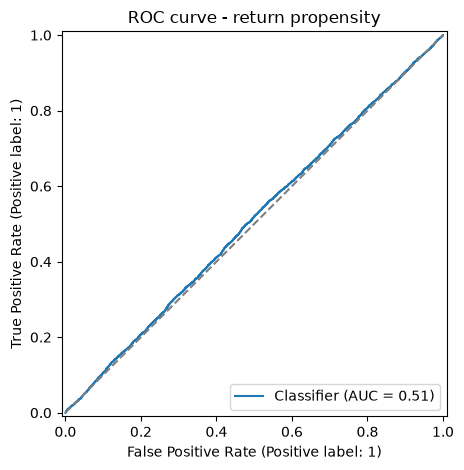

In [28]:
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

print("Confusion matrix [rows=actual, cols=predicted]:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification report:")
print(classification_report(y_test, y_pred, digits=3))
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba):.3f}")

RocCurveDisplay.from_predictions(y_test, y_proba)
plt.plot([0, 1], [0, 1], "--", color="gray")
plt.title("ROC curve - return propensity")
plt.tight_layout()
plt.show()

### Step 6 - Read the coefficients (this is the business insight)

A probability per item is useful for Ops, but the **coefficients are what you present to
category managers**. We convert each coefficient to an **odds ratio** (`exp(coef)`):

- odds ratio **> 1** → that attribute **raises** the odds of a return
- odds ratio **< 1** → that attribute **lowers** them

So "category = *X* has odds ratio 1.4" reads as "*X* items are ~40% more likely to be returned,
holding the other features constant". This is the sentence that changes a buying or QA
decision.

In [29]:
feat_names = model.named_steps["prep"].get_feature_names_out()
coefs = model.named_steps["clf"].coef_[0]

odds = pd.DataFrame({"feature": feat_names, "coef": coefs})
odds["odds_ratio"] = np.exp(odds["coef"])
odds = odds.sort_values("odds_ratio", ascending=False)

print("Top 8 features that RAISE return odds:")
print(odds.head(8).to_string(index=False))
print("\nTop 8 features that LOWER return odds:")
print(odds.tail(8).to_string(index=False))

Top 8 features that RAISE return odds:
                          feature     coef  odds_ratio
cat__category_Jumpsuits & Rompers 0.222821    1.249596
             cat__category_Skirts 0.130043    1.138877
              cat__category_Socks 0.074363    1.077198
            cat__category_Dresses 0.045283    1.046324
  cat__category_Outerwear & Coats 0.042893    1.043827
      cat__category_Clothing Sets 0.032294    1.032821
 cat__acquisition_source_Facebook 0.031367    1.031864
        cat__category_Accessories 0.028492    1.028901

Top 8 features that LOWER return odds:
                          feature      coef  odds_ratio
              cat__category_Jeans -0.037784    0.962921
cat__category_Suits & Sport Coats -0.038119    0.962599
           cat__category_Leggings -0.053090    0.948295
          cat__category_Underwear -0.058133    0.943524
          cat__category_Maternity -0.060574    0.941224
             cat__category_Shorts -0.072562    0.930008
  cat__category_Blazers & Jackets 

### Step 7 - Score every item and export for Power BI  ← the tool-to-tool handoff

Now we apply the trained model to the **full** dataset (not just the test split) to attach a
`return_probability` to every eligible item, then bucket it into a **risk band** for easy
dashboard filtering. The result is written to
`outputs/models/order_item_return_scores.csv`.

In Power BI: **Get Data → Text/CSV**, then relate
`order_item_return_scores[order_item_id]` to `fact_order_item[order_item_id]` (1-to-1). A card
showing `AVERAGE(return_probability)`, or a bar of High-risk item counts by category, becomes
the Operations **risk tile** — powered by the model, refreshed whenever you rerun this
notebook.

In [30]:
from pathlib import Path

items["return_probability"] = model.predict_proba(X)[:, 1]
# On this synthetic data the model AUC is ~0.5, so the absolute probabilities sit in a narrow
# band and fixed 0.33/0.66 cut-offs would drop everyone into one bucket. For the Power BI demo
# we band by *relative* rank (thirds of the score) so Ops still gets a working Low/Medium/High
# split; on real data with genuine signal you would band on absolute probability instead.
items["risk_band"] = pd.qcut(
    items["return_probability"], q=3, labels=["Low", "Medium", "High"]
)

out_dir = Path("../outputs/models")
out_dir.mkdir(parents=True, exist_ok=True)

export = items[["order_item_id", "return_probability", "risk_band"]]
out_path = out_dir / "order_item_return_scores.csv"
export.to_csv(out_path, index=False)

print(f"Wrote {len(export):,} rows -> {out_path.resolve()}")
print("\nRisk band distribution:")
print(export["risk_band"].value_counts())
export.head()

Wrote 63,463 rows -> C:\Users\phanh\data_analysis\p_projects\the_look_ecommerce\practice_analysis\outputs\models\order_item_return_scores.csv

Risk band distribution:
risk_band
Low       21155
Medium    21154
High      21154
Name: count, dtype: int64


,order_item_id,return_probability,risk_band
0,3035,0.490282,Low
1,3052,0.486535,Low
2,4134,0.469655,Low
3,4827,0.500808,Medium
4,6020,0.499269,Medium


### Step 8 - Write the findings

Fill in after running the cells above. A complete finding states:

- **Model quality** — the ROC-AUC, and in plain words how much better than a coin flip the
  model ranks risky items. Note the precision/recall trade-off Ops would live with.
- **The drivers** — the 2-3 attributes with the largest odds ratios up and down (from Step 6).
  *This* is the takeaway a category manager acts on.
- **The dashboard use** — how many items land in the **High** risk band, and what Ops does with
  that flag (e.g. extra QA on high-risk categories).
- **One caveat** — synthetic data: returns here are close to random, so expect a modest AUC and
  small coefficients. On real data the same pipeline typically finds much stronger, actionable
  signal. The *method* — honest split, balanced classes, AUC over accuracy, coefficients as
  insight — is the transferable skill.

> *(Your written conclusion goes here once you've seen the actual numbers.)*